# 2) pyGIMLi SRT manager

Next up, we want to get to know pyGIMLi's capabilities for refraction seismic data, accessible through in `pygimli.physics.traveltime`.

This package contains **tools, modelling operators, and managers** for refraction seismic data, supplying you with tools to **load, visualize, process and invert** your SRT field data.

The main classes are:

* `TravelTimeManager`

* `RefractionNLayer`

* `DataContainer[TT]`

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [1]:
# We import pyGIMLi and the traveltime module.

import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.physics.traveltime as tt
import numpy as np

## 1.1 Data import and sensor position definition

In [2]:
data = pg.load('PICK_P2own_topo.sgt')
print(np.array(data.sensors()))
data.sortSensorsX()
# plt.scatter(data.sensors()[:,0], data.sensors()[:,1])
ert_sensors = np.loadtxt('Coordinates_ERT_P2.txt', skiprows=0)
# plt.scatter(ert_sensors[:,0], ert_sensors[:,1])
yinterp = np.interp(data.sensors()[:,0], ert_sensors[:,0], ert_sensors[:,1])
# plt.scatter(data.sensors()[:,0], yinterp)
# data['err'] = 0.002
# print(data['err'])

[[ 0.     5.931  0.   ]
 [ 1.5    5.757  0.   ]
 [ 3.     5.516  0.   ]
 [ 4.5    5.355  0.   ]
 [ 6.     5.226  0.   ]
 [ 7.5    5.052  0.   ]
 [ 9.     4.898  0.   ]
 [10.5    4.851  0.   ]
 [12.     4.851  0.   ]
 [13.5    4.865  0.   ]
 [15.     4.76   0.   ]
 [16.5    4.686  0.   ]
 [18.     4.645  0.   ]
 [19.5    4.571  0.   ]
 [21.     4.476  0.   ]
 [22.5    4.252  0.   ]
 [24.     4.068  0.   ]
 [25.5    4.039  0.   ]
 [27.     3.936  0.   ]
 [28.5    3.761  0.   ]
 [30.     3.61   0.   ]
 [31.5    3.416  0.   ]
 [33.     3.162  0.   ]
 [34.5    3.027  0.   ]
 [36.     2.962  0.   ]
 [37.5    2.849  0.   ]
 [39.     2.75   0.   ]
 [40.5    2.6    0.   ]
 [42.     2.341  0.   ]
 [43.5    2.136  0.   ]
 [45.     1.913  0.   ]
 [46.5    1.829  0.   ]
 [48.     1.819  0.   ]
 [49.5    1.788  0.   ]
 [51.     1.738  0.   ]
 [52.5    1.672  0.   ]
 [54.     1.589  0.   ]
 [55.5    1.475  0.   ]
 [57.     1.322  0.   ]
 [58.5    1.305  0.   ]
 [60.     1.276  0.   ]
 [61.5    1.224 

In [3]:
new = np.zeros((len(data.sensors()), 3))
new[:,0] = data.sensors()[:,0]
new[:,1] = yinterp
print(new)
data.setSensorPositions(new)
data.save("../joint/SRT_P2_coords.sgt")

[[  0.     299.29     0.    ]
 [  0.75   299.2225   0.    ]
 [  1.5    299.15     0.    ]
 [  2.25   299.07     0.    ]
 [  3.     298.98     0.    ]
 [  3.75   298.8825   0.    ]
 [  4.5    298.785    0.    ]
 [  5.25   298.685    0.    ]
 [  6.     298.58     0.    ]
 [  6.75   298.52     0.    ]
 [  7.5    298.46     0.    ]
 [  8.25   298.395    0.    ]
 [  9.     298.32     0.    ]
 [  9.75   298.2375   0.    ]
 [ 10.5    298.21     0.    ]
 [ 11.25   298.21     0.    ]
 [ 12.     298.21     0.    ]
 [ 12.75   298.21     0.    ]
 [ 13.5    298.205    0.    ]
 [ 14.25   298.1975   0.    ]
 [ 15.     298.19     0.    ]
 [ 15.75   298.1825   0.    ]
 [ 16.5    298.15     0.    ]
 [ 17.25   298.1025   0.    ]
 [ 18.     298.05     0.    ]
 [ 18.75   298.005    0.    ]
 [ 19.5    297.96     0.    ]
 [ 20.25   297.9075   0.    ]
 [ 21.     297.84     0.    ]
 [ 21.75   297.765    0.    ]
 [ 22.5    297.66     0.    ]
 [ 23.25   297.54     0.    ]
 [ 24.     297.42     0.    ]
 [ 24.75  

1

## 1.2 Visualization of first picks and traveltime data

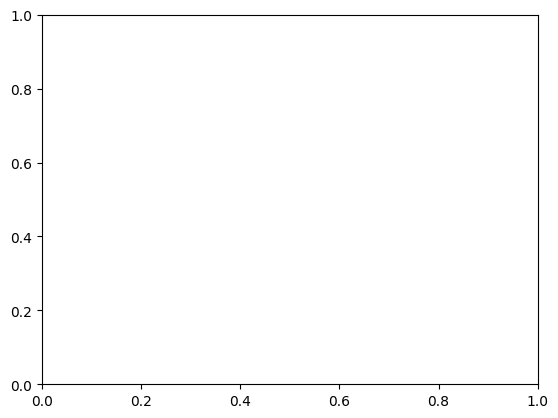

In [4]:
fig, ax = plt.subplots()
lines = tt.drawFirstPicks(ax, data)

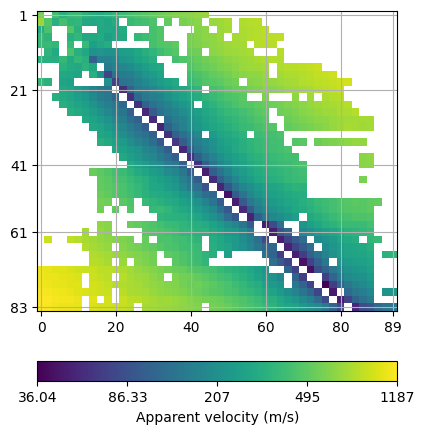

In [5]:
mgr = tt.TravelTimeManager(data)

# Alternatively, one can plot a matrix plot of apparent velocities which is the
# more general function also making sense for crosshole data.

ax, cbar = mgr.showData()

## 1.3 Mesh generation

Finally, we call the `invert` method and plot the result.The mesh is created
based on the sensor positions on-the-fly.



14/09/26 - 08:38:23 - pyGIMLi - INFO - Found 2 regions.
14/09/26 - 08:38:23 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
14/09/26 - 08:38:23 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 08:38:23 - pyGIMLi - INFO - Creating refined mesh (secnodes: 3) to solve forward task.


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

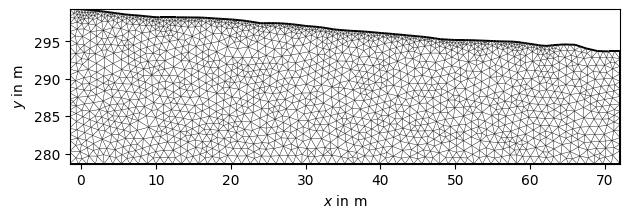

In [6]:
from pygimli import meshtools as mt
mesh = mt.createParaMesh(data, paraDX=0.5, paraDepth=15, paraMaxCellSize=0.75)
mgr.fop.setMesh(mesh)
pg.show(mgr.fop.paraDomain)

## 1.5 First inversion and quality evaluation

In [11]:
mgr.invert(paraMaxCellSize=0.5, lam=27, vTop=500, vBottom=3500, verbose=1)

14/09/26 - 08:42:00 - pyGIMLi - INFO - Create gradient starting model. 500: 3500
14/09/26 - 08:42:00 - pyGIMLi - INFO - Created startmodel from forward operator:7621, min/max=0.000286/0.002000
14/09/26 - 08:42:00 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x000002485793D2B0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.0013/0.06
min/max (error): 3%/76.86%
min/max (start model): 2.9e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  201.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   55.90 (dPhi = 71.78%) lam: 27.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    3.17 (dPhi = 91.71%) lam: 27.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.42 (dPhi = 33.45%) lam: 27.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.19 (dPhi = 10.39%) lam: 27.0
----------------------------------------------------------------

7621 [113.771401905608,...,5047.671069693596]

Look at the fit between measured (crosses) and modelled (lines) traveltimes.



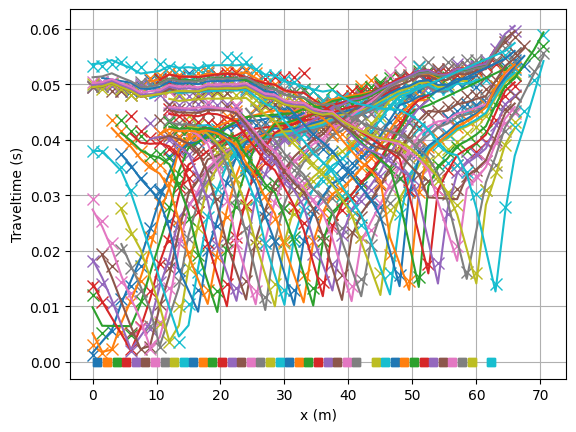

In [12]:
mgr.showFit(firstPicks=True)

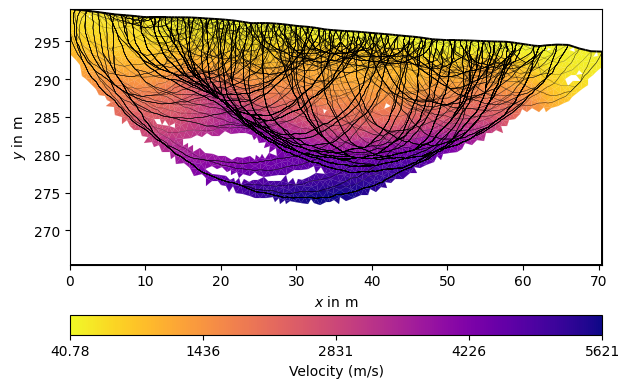

In [13]:
ax, cbar = mgr.showResult(logScale=False, cMap="plasma_r",
                          coverage=mgr.standardizedCoverage())
rays = mgr.drawRayPaths(ax=ax, color="k", lw=0.3, alpha=0.5)

# mgr.coverage() yields the ray coverage in m and standardizedCoverage as 0/1

C:\Users\Nino Menzel\AppData\Local\Temp\ipykernel_24404\3394846230.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  top = cm.get_cmap('Blues_r', 128)
C:\Users\Nino Menzel\AppData\Local\Temp\ipykernel_24404\3394846230.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bottom = cm.get_cmap('Oranges', 128)
14/09/26 - 08:42:45 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


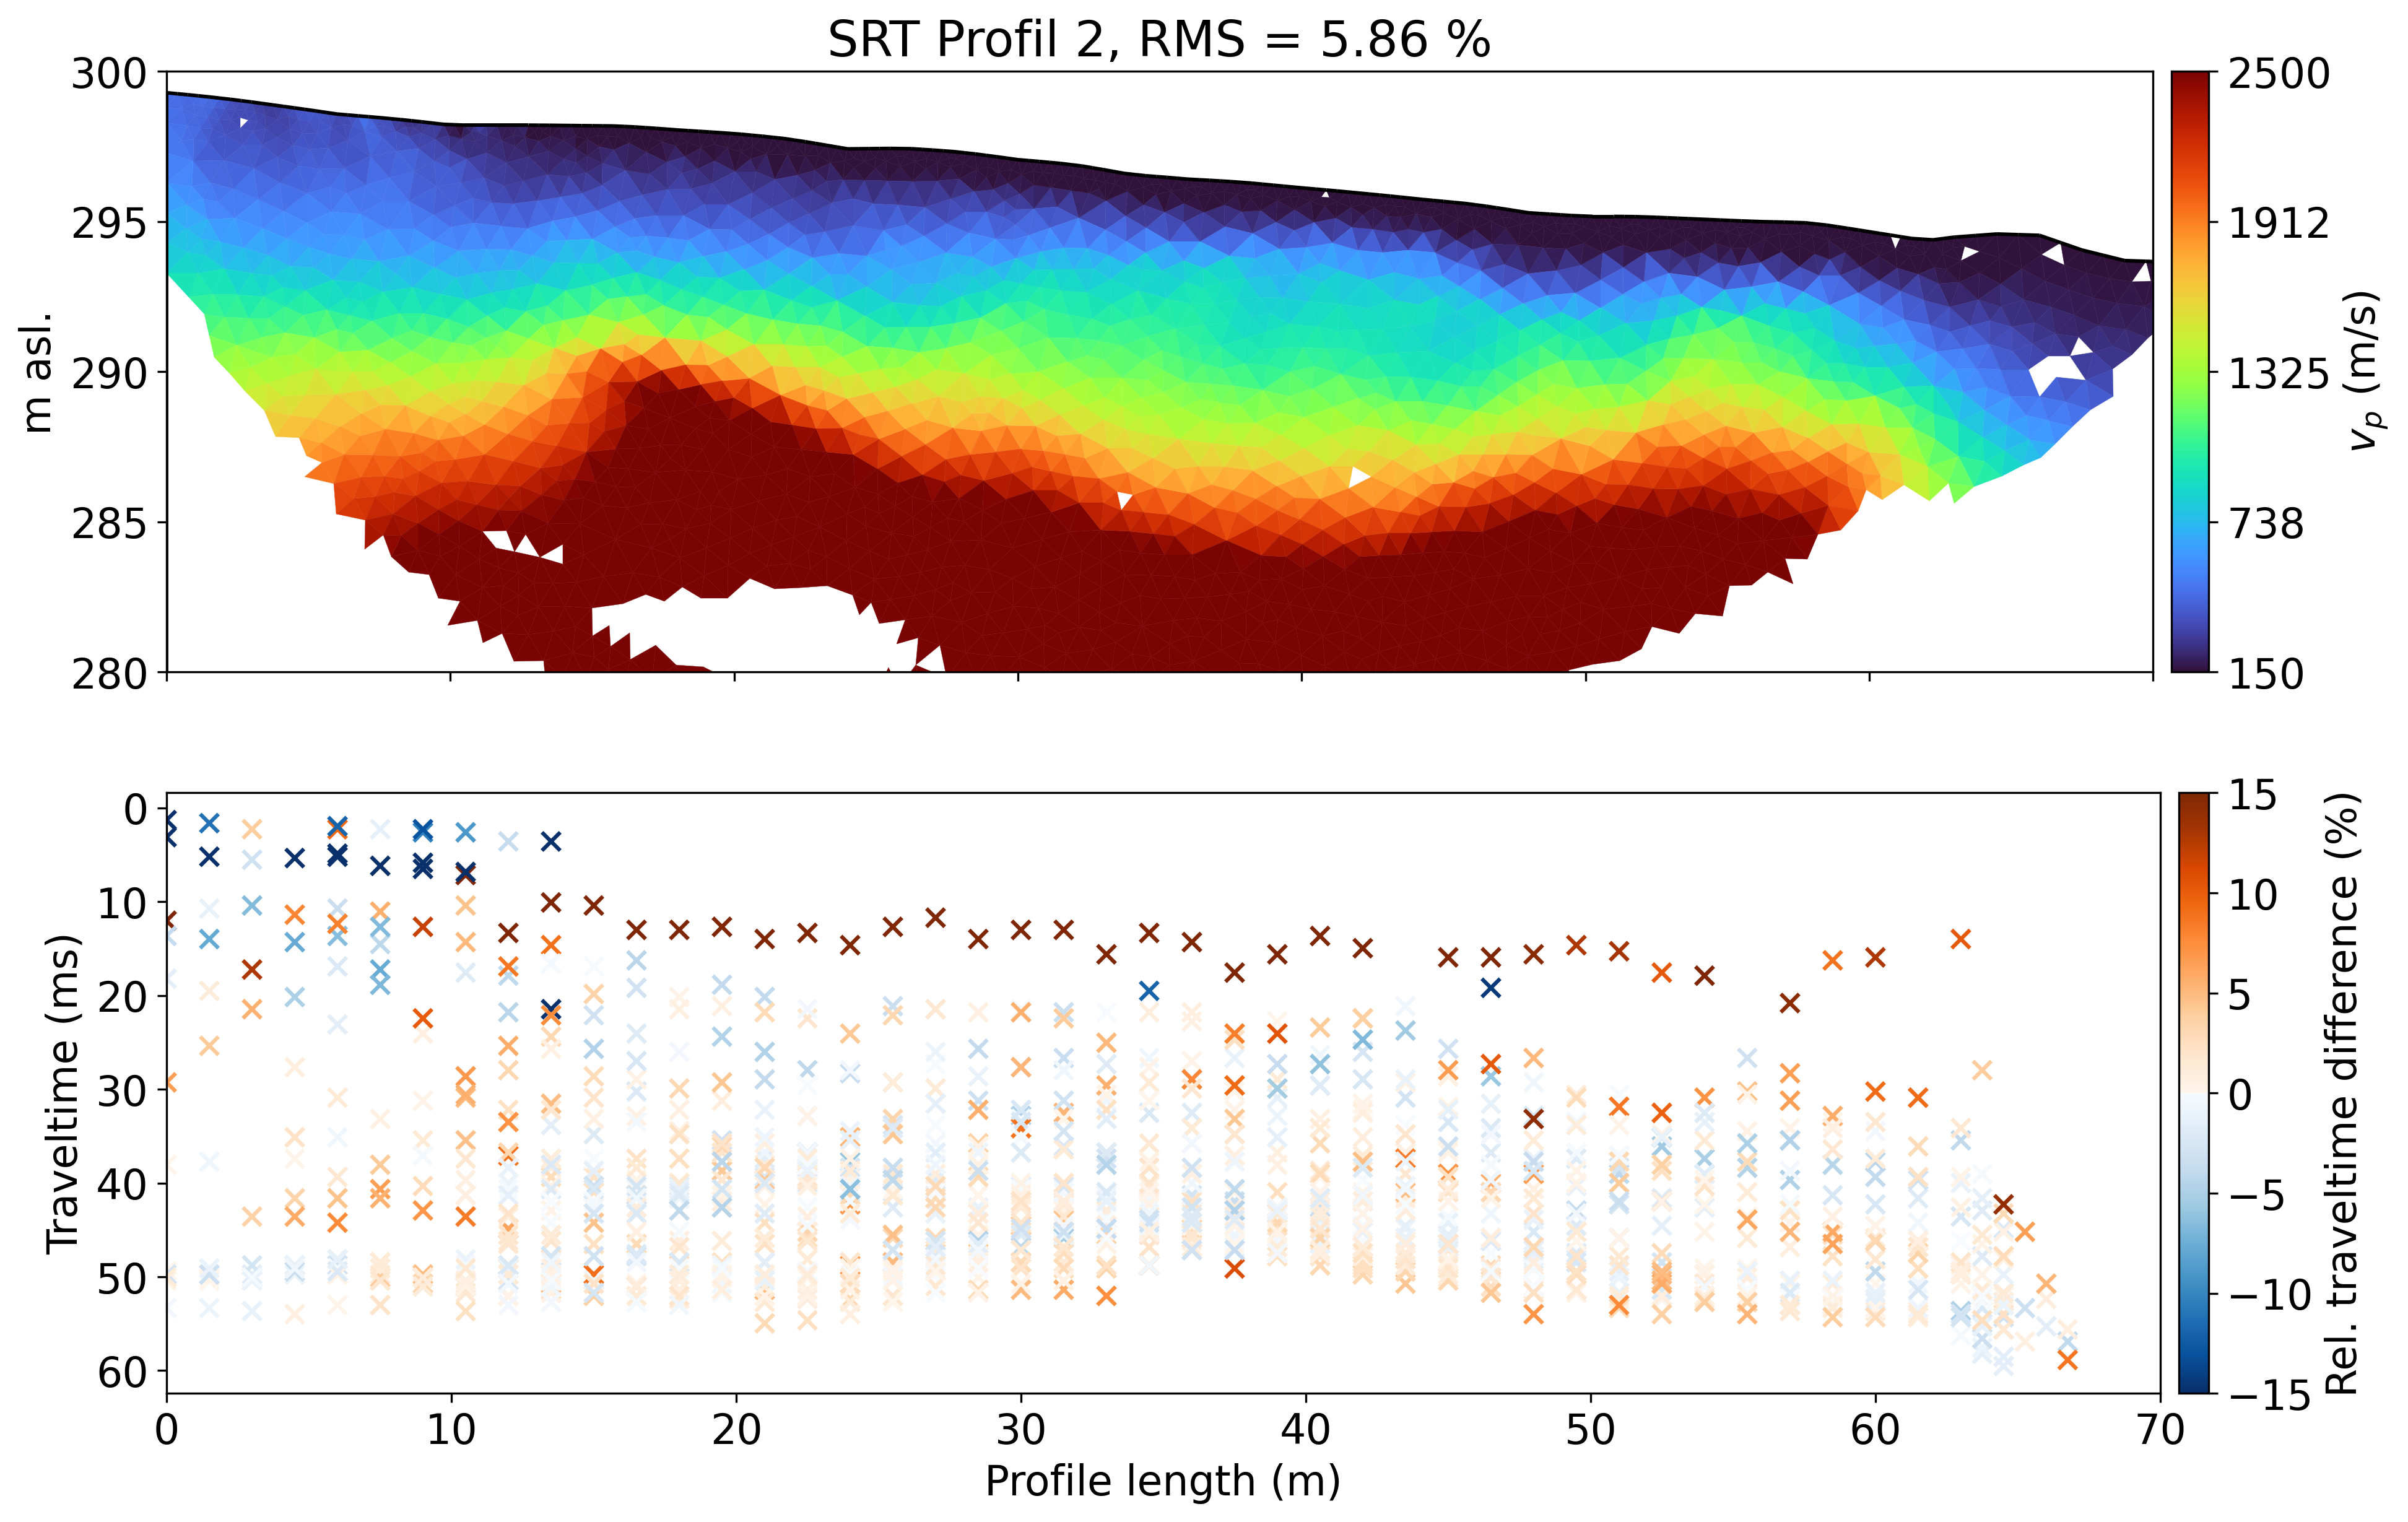

In [14]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['font.size'] = 16

top = cm.get_cmap('Blues_r', 128)
bottom = cm.get_cmap('Oranges', 128)


newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
cmap = ListedColormap(newcolors, name='OrangeBlue')

vKW = dict(logScale=False, cMin=150, cMax=2500, 
           ylabel = "Depth (m)",orientation = 'vertical', cMap = 'turbo', 
        label = r"$v_p$ (m/s)", coverage=mgr.standardizedCoverage())


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=300)


mgr.showResult(ax = ax1, **vKW)
ax1.set_aspect("auto")
ax1.axis(xmin = 0, xmax=70, ymin=280, ymax=300)
ax1.set_title(f"SRT Profil 2, RMS = {mgr.inv.relrms():.2f} %")
ax1.set_ylabel("m asl.")
ax1.set_xlabel("")


divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='1.5%', pad=0.1)

raytracing = mgr.simulate(mgr.paraDomain, data, slowness = 1/mgr.model)

diff = ((data["t"]-raytracing["t"])/raytracing["t"])*100
im = ax2.scatter(data['g']*.75, data['t']*1000, s=50, c=diff, marker="x", vmin=-15, vmax=15, cmap=cmap)


ax2.axis(xmin=0,xmax=70)
ax2.set_ylabel("Traveltime (ms)")
fig.colorbar(im, cax=cax, label="Rel. traveltime difference (%)")
ax2.invert_yaxis()
ax2.set_ylabel("Traveltime (ms)")
ax2.set_xlabel("Profile length (m)")
plt.show()


fig.tight_layout()

In [ ]:
np.savetxt("coverage_SRT.txt", mgr.standardizedCoverage())
m = pg.Mesh(mgr.paraDomain)
m['Traveltime'] = mgr.paraModel(mgr.model)
m.exportVTK(f'inv_SRT')